# Modelo Propuesto Multimodal: MTDE-Net

Este cuaderno implementa el entrenamiento y la evaluación de la arquitectura multimodal **MTDE-Net**.

### Características:
1. **Rama Visual Lite:** Conserva el backbone extractor basado en bloques residuales con atención dual en todas las etapas.
2. **Rama Tabular Enriquecida:** Incorpora un vector de 10 dimensiones:
   * Variables ambientales (`ambient_temp_C`, `ambient_rh_pct`)
   * Variables del sustrato físicas (`surface` - Madera/Vidrio codificadas)
   * Variables estadísticas y térmicas extratadas de la huella (`img_tmax_C`, `img_tstd_C`, `delta_tmean_C`, `delta_tstd_C`, `hot_area_px_p95`, `hot_delta_tmean_C_p95`)
3. **Fusión Intermedia y Regresión:** Fusiona ambas ramas y realiza la regresión lineal utilizando la pérdida unificada de raíz cuadrada.

In [1]:
import sys
import random
from pathlib import Path

# Añadir el directorio raíz al path de Python para permitir importaciones correctas
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from src.models.mtde_net import MTDE_Net
from src.loaders.mtde_net_loader import MultimodalThermalDataset
from src.utils import SqrtScaledMSELoss, eval_mtde_net_metrics, build_subject_split_plan, subject_summary, plot_learning_curves, plot_prediction_calibration, plot_error_by_time_window

### 1. Semilla Global y Reproducibilidad

In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### 2. Configuración General (Hiperparámetros)

In [3]:
CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    "batch_size": 16,
    "lr": 0.001,
    "weight_decay": 0.0005,
    "min_time_s": 0.0,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "time_scale": 30.0,
}

### 3. Carga del Dataset y Partición por Sujeto (Sin Leakage)

In [4]:
dev = CONFIG["device"]
metadata_path = "../processed_data/metadata_train.csv"

ds_full = MultimodalThermalDataset(metadata_csv=metadata_path, is_train=False, min_time_s=CONFIG["min_time_s"], time_scale=CONFIG["time_scale"])
df = ds_full.df

print("Resumen de sujetos en metadata:")
print(subject_summary(df))

plan = build_subject_split_plan(
    df,
    n_splits=9,
    seed=42,
    test_subjects=["tania", "matias"],
    reserve_incomplete_for_test=True,
)

print("\nPlan de partición:")
print(f"Sujetos de Test ({plan.num_test_subjects}): {plan.test_subjects} (Muestras: {plan.num_test_samples})")
print(f"Sujetos de Train/Val ({plan.num_trainval_subjects}): {plan.trainval_subjects} (Muestras: {plan.num_trainval_samples})")
print(f"Número de folds para CV: {len(plan.folds)}")
for f in plan.folds:
    print(f"  Fold {f.fold}: Train subjects {f.train_subjects} ({len(f.train_indices)} muestras), Val subjects {f.val_subjects} ({len(f.val_indices)} muestras)")

Resumen de sujetos en metadata:
         name  n_sequences  n_samples      surface  gender  is_complete
0      alonso            6        282  glass, wood    male         True
1      angelo            6        281  glass, wood    male         True
2     claudia            6        282  glass, wood  female         True
3     eduardo            1         47         wood    male        False
4     esteban            6        276  glass, wood    male         True
5    fabricio            6        277  glass, wood    male         True
6   juandiego            6        280  glass, wood    male         True
7      matias            6        282  glass, wood    male         True
8     melissa            6        282  glass, wood  female         True
9      renato            6        278  glass, wood    male         True
10      tania            6        278  glass, wood  female         True
11    yohamin            6        276  glass, wood    male         True

Plan de partición:
Sujetos de T

### 4. Inicialización del Modelo MTDE-Net

In [5]:
model = MTDE_Net(tabular_dim=10).to(dev)
print(f"Parámetros totales de MTDE-Net: {sum(p.numel() for p in model.parameters()):,}")

Parámetros totales de MTDE-Net: 1,325,613


--- 
## 5. Ciclo de Entrenamiento y Evaluación del Modelo (Baseline)

Esta sección entrena el modelo MTDE-Net con parámetros por defecto.

In [6]:
BASELINE_CONFIG = {
    "epochs": 120,
    "patience": 15,
    "min_delta": 1.0,
    "batch_size": 16,
    "lr": 0.001,
    "weight_decay": 0.0005,
}

set_seed(42)

fold_metrics_base = []
histories_base = []

print("=" * 60)
print("FASE A: VALIDACIÓN CRUZADA POR SUJETO (BASELINE)")
print("=" * 60)

for fold in plan.folds:
    print(f"\nEntrenando Fold {fold.fold}/{len(plan.folds)} <<<")
    print(f"Train subjects: {fold.train_subjects}")
    print(f"Val subjects: {fold.val_subjects}")
    
    train_ds = MultimodalThermalDataset(
        metadata_csv=metadata_path,
        is_train=True,
        min_time_s=CONFIG["min_time_s"],
        time_scale=CONFIG["time_scale"],
        indices=fold.train_indices
    )
    val_ds = MultimodalThermalDataset(
        metadata_csv=metadata_path,
        is_train=False,
        min_time_s=CONFIG["min_time_s"],
        time_scale=CONFIG["time_scale"],
        indices=fold.val_indices,
        means=train_ds.means,
        stds=train_ds.stds
    )
    
    train_loader = DataLoader(train_ds, batch_size=BASELINE_CONFIG["batch_size"], shuffle=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=BASELINE_CONFIG["batch_size"])
    train_eval_loader = DataLoader(train_ds, batch_size=BASELINE_CONFIG["batch_size"])
    
    model = MTDE_Net(tabular_dim=10).to(dev)
    crit = SqrtScaledMSELoss(scale=None)
    opt = torch.optim.AdamW(model.parameters(), lr=BASELINE_CONFIG["lr"], weight_decay=BASELINE_CONFIG["weight_decay"])
    scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)
    
    best_val_mae = float("inf")
    no_imp = 0
    best_metrics = None
    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
    
    for ep in range(1, BASELINE_CONFIG["epochs"] + 1):
        model.train()
        train_loss, n = 0.0, 0
        for x_img, x_tab, y in train_loader:
            x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
            opt.zero_grad(set_to_none=True)
            loss = crit(model(x_img, x_tab), y)
            loss.backward()
            opt.step()
            train_loss += loss.item() * x_img.size(0)
            n += x_img.size(0)
            
        scheduler.step()
        
        model.eval()
        val_loss, val_n = 0.0, 0
        with torch.no_grad():
            for val_x_img, val_x_tab, val_y in val_loader:
                val_x_img, val_x_tab, val_y = val_x_img.to(dev), val_x_tab.to(dev), val_y.to(dev)
                loss = crit(model(val_x_img, val_x_tab), val_y)
                val_loss += loss.item() * val_x_img.size(0)
                val_n += val_x_img.size(0)
        val_loss /= val_n
        
        val_m = eval_mtde_net_metrics(model, val_loader, dev, scale=CONFIG["time_scale"])
        train_m = eval_mtde_net_metrics(model, train_eval_loader, dev, scale=CONFIG["time_scale"])
        
        v_mae = val_m["mae"]
        is_best = v_mae < best_val_mae - CONFIG["min_delta"]
        if is_best:
            best_val_mae, no_imp = v_mae, 0
            best_metrics = val_m
            torch.save(model.state_dict(), f"../MTDE_Net_baseline_fold{fold.fold}.pt")
        else:
            no_imp += 1
            
        history["train_loss"].append(train_loss / n)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_m["mae"])
        history["val_mae"].append(v_mae)
        
        if no_imp >= CONFIG["patience"]:
            break
            
    print(f"Fold {fold.fold} finalizado. Mejor Val MAE: {best_val_mae:.2f}s")
    fold_metrics_base.append(best_metrics)
    histories_base.append(history)

df_folds_base = pd.DataFrame(fold_metrics_base)
cv_mean_base = df_folds_base.mean().to_dict()
cv_std_base = df_folds_base.std().to_dict()

print("\n" + "=" * 60)
print("FASE A: ENTRENAMIENTO FINAL EN ALL TRAINVAL Y EVAL EN TEST (BASELINE)")
print("=" * 60)

trainval_ds = MultimodalThermalDataset(
    metadata_csv=metadata_path,
    is_train=True,
    min_time_s=CONFIG["min_time_s"],
    time_scale=CONFIG["time_scale"],
    indices=plan.trainval_indices
)
test_ds = MultimodalThermalDataset(
    metadata_csv=metadata_path,
    is_train=False,
    min_time_s=CONFIG["min_time_s"],
    time_scale=CONFIG["time_scale"],
    indices=plan.test_indices,
    means=trainval_ds.means,
    stds=trainval_ds.stds
)

trainval_loader = DataLoader(trainval_ds, batch_size=BASELINE_CONFIG["batch_size"], shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=BASELINE_CONFIG["batch_size"])

model_base = MTDE_Net(tabular_dim=10).to(dev)
crit = SqrtScaledMSELoss(scale=None)
opt = torch.optim.AdamW(model_base.parameters(), lr=BASELINE_CONFIG["lr"], weight_decay=BASELINE_CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[30, 60, 80], gamma=0.8)

avg_epochs_base = int(np.mean([len(h["train_loss"]) - CONFIG["patience"] for h in histories_base]))
avg_epochs_base = max(10, avg_epochs_base)
print(f"Entrenando modelo final por {avg_epochs_base} épocas...")

for ep in range(1, avg_epochs_base + 1):
    model_base.train()
    train_loss, n = 0.0, 0
    for x_img, x_tab, y in trainval_loader:
        x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
        opt.zero_grad(set_to_none=True)
        loss = crit(model_base(x_img, x_tab), y)
        loss.backward()
        opt.step()
        train_loss += loss.item() * x_img.size(0)
        n += x_img.size(0)
    scheduler.step()

torch.save(model_base.state_dict(), "../MTDE_Net_baseline.pt")
baseline_metrics = eval_mtde_net_metrics(model_base, test_loader, dev, scale=CONFIG["time_scale"])
print(f"Modelo Baseline Final evaluado en Test Set. MAE: {baseline_metrics['mae']:.2f}s | RMSE: {baseline_metrics['rmse']:.2f}s")

FASE A: VALIDACIÓN CRUZADA POR SUJETO (BASELINE)

Entrenando Fold 1/9 <<<
Train subjects: ['alonso', 'angelo', 'claudia', 'fabricio', 'juandiego', 'melissa', 'renato', 'yohamin']
Val subjects: ['esteban']


Fold 1 finalizado. Mejor Val MAE: 28.06s

Entrenando Fold 2/9 <<<
Train subjects: ['angelo', 'claudia', 'esteban', 'fabricio', 'juandiego', 'melissa', 'renato', 'yohamin']
Val subjects: ['alonso']


Fold 2 finalizado. Mejor Val MAE: 25.99s

Entrenando Fold 3/9 <<<
Train subjects: ['alonso', 'angelo', 'claudia', 'esteban', 'fabricio', 'juandiego', 'melissa', 'yohamin']
Val subjects: ['renato']


Fold 3 finalizado. Mejor Val MAE: 28.15s

Entrenando Fold 4/9 <<<
Train subjects: ['alonso', 'angelo', 'esteban', 'fabricio', 'juandiego', 'melissa', 'renato', 'yohamin']
Val subjects: ['claudia']


Fold 4 finalizado. Mejor Val MAE: 26.38s

Entrenando Fold 5/9 <<<
Train subjects: ['alonso', 'angelo', 'claudia', 'esteban', 'juandiego', 'melissa', 'renato', 'yohamin']
Val subjects: ['fabricio']


...

Fold 6 finalizado. Mejor Val MAE: 70.55s

Entrenando Fold 7/9 <<<
Train subjects: ['alonso', 'claudia', 'esteban', 'fabricio', 'juandiego', 'melissa', 'renato', 'yohamin']
Val subjects: ['angelo']


Fold 7 finalizado. Mejor Val MAE: 34.10s

Entrenando Fold 8/9 <<<
Train subjects: ['alonso', 'angelo', 'claudia', 'esteban', 'fabricio', 'melissa', 'renato', 'yohamin']
Val subjects: ['juandiego']


Fold 8 finalizado. Mejor Val MAE: 24.44s

Entrenando Fold 9/9 <<<
Train subjects: ['alonso', 'angelo', 'claudia', 'esteban', 'fabricio', 'juandiego', 'melissa', 'renato']
Val subjects: ['yohamin']


Fold 9 finalizado. Mejor Val MAE: 21.66s

FASE A: ENTRENAMIENTO FINAL EN ALL TRAINVAL Y EVAL EN TEST (BASELINE)
Entrenando modelo final por 25 épocas...


Modelo Baseline Final evaluado en Test Set. MAE: 48.94s | RMSE: 65.13s


--- 
## 6. Tabla Resumen de Resultados Finales

Esta celda autogenera una tabla markdown limpia que reporta el rendimiento del modelo baseline en validación y test.

In [ ]:
summary_data = {
    "Métrica": [
        "MAE CV (Validación)",
        "RMSE CV (Validación)",
        "R² CV (Validación)",
        "MAE Test (Generalización)",
        "RMSE Test (Generalización)",
        "R² Test (Generalización)",
        "MAPE Test (Error %)",
        "Acc@60s Test",
        "Acc@120s Test"
    ],
    "Valor (Baseline)": [
        f"{cv_mean_base['mae']:.2f} ± {cv_std_base['mae']:.2f} s",
        f"{cv_mean_base['rmse']:.2f} ± {cv_std_base['rmse']:.2f} s",
        f"{cv_mean_base['r2']:.4f} ± {cv_std_base['r2']:.4f}",
        f"{baseline_metrics['mae']:.2f} s",
        f"{baseline_metrics['rmse']:.2f} s",
        f"{baseline_metrics['r2']:.4f}",
        f"{baseline_metrics['mape']:.2f} %",
        f"{baseline_metrics['acc60']:.2f} %",
        f"{baseline_metrics['acc120']:.2f} %"
    ]
}

df_summary = pd.DataFrame(summary_data)
print("\nResumen de Resultados para MTDE-Net (Tesis)")
df_summary

--- 
## 7. Visualización de Resultados Experimentales y Curvas de Aprendizaje

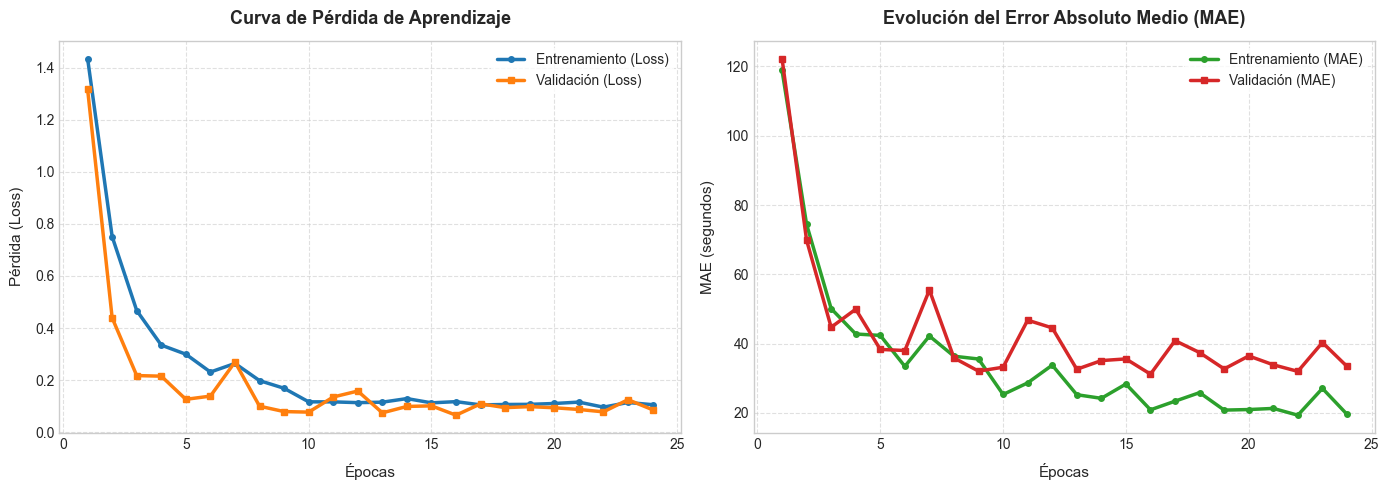

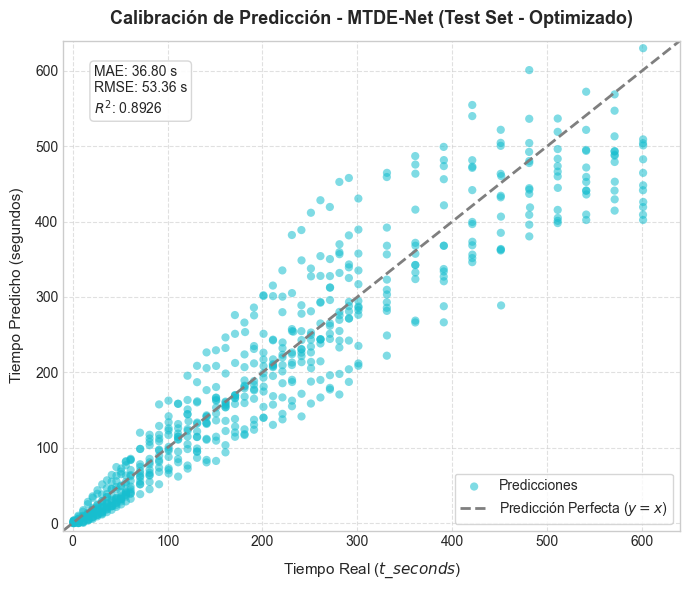

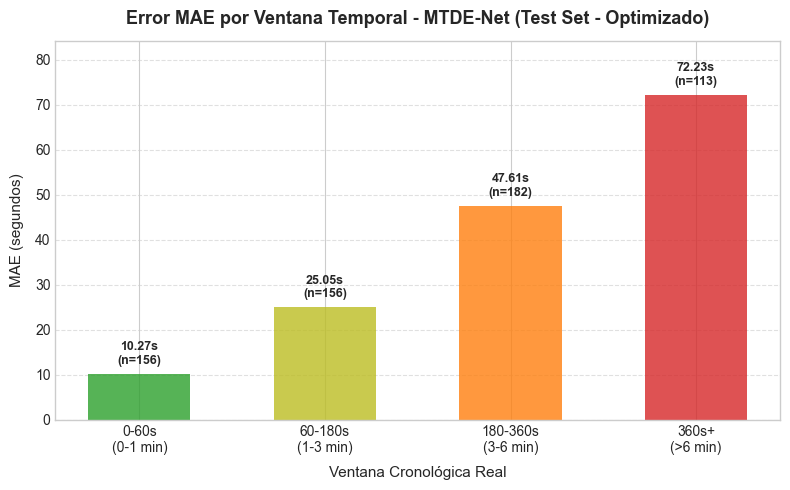

In [ ]:
# Cargar el modelo final entrenado para graficar y evaluar predicciones en Test
model_base.load_state_dict(torch.load("../MTDE_Net_baseline.pt"))
model_base.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x_img, x_tab, y in test_loader:
        x_img, x_tab, y = x_img.to(dev), x_tab.to(dev), y.to(dev)
        pred = model_base(x_img, x_tab)
        # Desescalar predicciones y reales
        y_true.extend((y.cpu().numpy() * CONFIG["time_scale"]).tolist())
        y_pred.extend((pred.cpu().numpy() * CONFIG["time_scale"]).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 1. Curvas de aprendizaje del último fold de validación cruzada (Baseline)
plot_learning_curves(histories_base[-1])

# 2. Gráfico de Calibración de Predicciones en el Test Set
plot_prediction_calibration(y_true, y_pred, model_name="MTDE-Net (Test Set - Baseline)")

# 3. Distribución del error por ventana temporal en el Test Set
plot_error_by_time_window(y_true, y_pred, model_name="MTDE-Net (Test Set - Baseline)")
